In [1]:
import cv2
import numpy as np

In [4]:
left_rectified  = cv2.imread(r'./test_left.jpeg')
right_rectified  = cv2.imread(r'./test_right.jpeg')

PATTERN_SIZE = (9,6)
criteria = (cv2.TERM_CRITERIA_EPS+cv2.TERM_CRITERIA_MAX_ITER, 30, 1e-3)

res_left, corners_left = cv2.findChessboardCorners(left_rectified, PATTERN_SIZE)
res_right, corners_right = cv2.findChessboardCorners(right_rectified, PATTERN_SIZE)


cv2.drawChessboardCorners(left_rectified, (9,6), corners_left, res_left)
cv2.drawChessboardCorners(right_rectified, (9,6), corners_right, res_right)


x = int(corners_left[0][0][0])
y = int(corners_left[0][0][1])
cv2.circle(left_rectified, (x, y), 4, (255, 255, 255), 2, 2)
x = int(corners_left[1][0][0])
y = int(corners_left[1][0][1])
cv2.circle(left_rectified, (x, y), 4, (0, 255, 255), 2, 2)
print(x, y)
x = int(corners_right[0][0][0])
y = int(corners_right[0][0][1])
cv2.circle(right_rectified, (x, y), 4, (255, 255, 255), 2, 2)
x = int(corners_right[1][0][0])
y = int(corners_right[1][0][1])
cv2.circle(right_rectified, (x, y), 4, (0, 255, 255), 2, 2)
print(x, y)
cv2.imshow('left_rectified', left_rectified)
cv2.imshow('right_rectified', right_rectified)
cv2.waitKey(0)
cv2.destroyAllWindows()

837 114
766 113


In [6]:
left_rectified  = cv2.imread(r'./Test4_left.jpeg')
right_rectified  = cv2.imread(r'./Test4_right.jpeg')

PATTERN_SIZE = (9,6)
criteria = (cv2.TERM_CRITERIA_EPS+cv2.TERM_CRITERIA_MAX_ITER, 30, 1e-3)

res_left, corners_left = cv2.findChessboardCorners(left_rectified, PATTERN_SIZE)
res_right, corners_right = cv2.findChessboardCorners(right_rectified, PATTERN_SIZE)


cv2.drawChessboardCorners(left_rectified, (9,6), corners_left, res_left)
cv2.drawChessboardCorners(right_rectified, (9,6), corners_right, res_right)


x = int(corners_left[0][0][0])
y = int(corners_left[0][0][1])
cv2.circle(left_rectified, (x, y), 4, (255, 255, 255), 2, 2)
x = int(corners_left[1][0][0])
y = int(corners_left[1][0][1])
cv2.circle(left_rectified, (x, y), 4, (0, 255, 255), 2, 2)
print(x, y)
x = int(corners_right[0][0][0])
y = int(corners_right[0][0][1])
cv2.circle(right_rectified, (x, y), 4, (255, 255, 255), 2, 2)
x = int(corners_right[1][0][0])
y = int(corners_right[1][0][1])
cv2.circle(right_rectified, (x, y), 4, (0, 255, 255), 2, 2)
print(x, y)
cv2.imshow('left_rectified', left_rectified)
cv2.imshow('right_rectified', right_rectified)
cv2.waitKey(0)
cv2.destroyAllWindows()

455 520
328 521


https://courses.cs.washington.edu/courses/cse455/09wi/Lects/lect16.pdf

In [14]:
focal_length_px = 1.81775939e+03 # in px
baseline = 9 # in cm

In [15]:
xr = corners_right[0][0][0] 
xl = corners_left[0][0][0] 
yr = corners_right[0][0][1] 
yl = corners_left[0][0][1] 

(xl, yl), (xr, yr)

((456.06256, 561.21893), (328.53815, 562.18854))

In [16]:
xr = corners_right[1][0][0] 
xl = corners_left[1][0][0] 
yr = corners_right[1][0][1] 
yl = corners_left[1][0][1] 

(xl, yl), (xr, yr)

((455.81958, 520.3664), (328.5392, 521.4565))

In [17]:
xr = corners_right[0][0][0] 
xl = corners_left[0][0][0] 
yr = corners_right[0][0][1] 
yl = corners_left[0][0][1] 
horizontal_diff_in_px = xl-xr
print('horizontal disparity in pixels:',round(horizontal_diff_in_px))


z1 = (focal_length_px*baseline)/horizontal_diff_in_px
x1 = (xl*z1)/focal_length_px
y1 = (yl*z1)/focal_length_px

print("x: ",x1, "cm")
print("y ",y1, "cm")
print("z: ", z1 ,"cm")

horizontal disparity in pixels: 128
x:  32.18648820691503 cm
y  39.6078698740284 cm
z:  128.28786260474018 cm


In [18]:
xr = corners_right[1][0][0] 
xl = corners_left[1][0][0] 
yr = corners_right[1][0][1] 
yl = corners_left[1][0][1] 
horizontal_diff_in_px = xl-xr
print('horizontal disparity in pixels:',round(horizontal_diff_in_px))
z2 = (focal_length_px*baseline)/horizontal_diff_in_px
x2 = (xl*z2)/focal_length_px
y2 = (yl*z2)/focal_length_px

print("x: ",x2, "cm")
print("y ",y2, "cm")
print("z: ", z2 ,"cm")

horizontal disparity in pixels: 127
x:  32.23102181564204 cm
y  36.795129765270914 cm
z:  128.5338434663918 cm


In [19]:
x_delta = (x2-x1)
y_delta = (y2-y1)
z_delta = (z2-z1)

x_delta, y_delta, z_delta

(0.044533608727007845, -2.812740108757488, 0.24598086165161703)

In [20]:
np.sqrt((x_delta**2) +(y_delta**2)+(z_delta**2))

2.823826614014785

LEFT UNDISTORTED AND RECTIFIED 

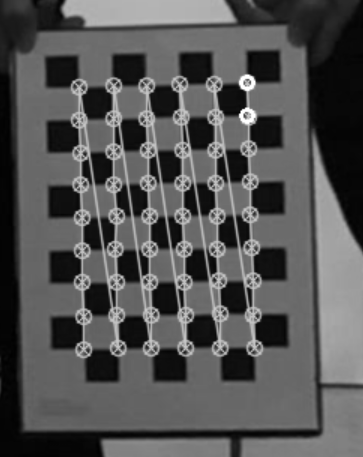


RIGHT UNDISTORTED AND RECTIFIED

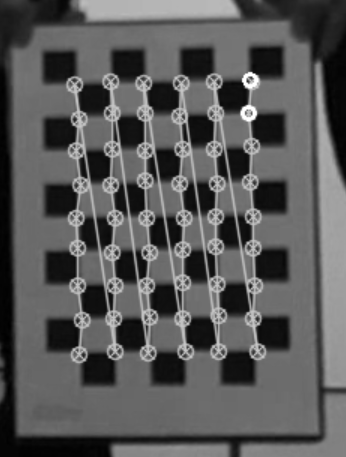

HIGH ERROR IN THE Z AXIS  BECAUSE OF THE RIGHT IMAGE CALIBRATION BEING DONE POORLY SO THE HORIZONTAL DISPARITY FOR THE POINT 2 (SECOND OUTLINED CIRCLE FROM THE TOP) IS OVER ESTIMATED COMPARED TO POINT 1 (FIRST OUTLINED CIRCLE FROM THE TOP)

ANOTHER LEFT UNDISTORTED IMAGE

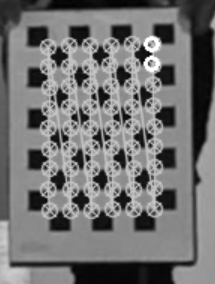

ANOTHER RIGHT UNDISTORTED IMAGE

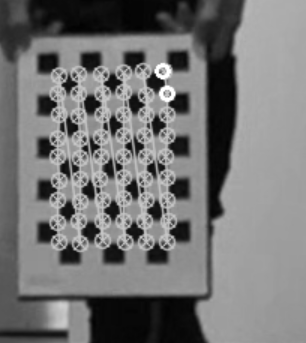